In [3]:
import numpy as np
import pandas as pd
import polars as pl
from polars import selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OrdinalEncoder, OneHotEncoder, TargetEncoder, Binarizer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split,cross_validate,KFold,GridSearchCV,RandomizedSearchCV
from sklearn.metrics import root_mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.feature_selection import SelectFromModel
from sklearn.utils.validation import check_is_fitted
from typing import cast
from category_encoders import CountEncoder
import sys
sys.path.append(r"../baseline_v2")
from add_features import add_modified_features
from preprocess import build_preprocessor, build_target_transformer


%matplotlib inline

warnings.filterwarnings('ignore')

## Data Preprocessing

### Cast

In [4]:
def mycast(df):
    df['MSSubClass'] = df['MSSubClass'].apply(str)
    df['YrSold'] = df['YrSold'].astype(str)
    df['MoSold'] = df['MoSold'].astype(str)
    return df

### Clean

In [5]:
def clean(df):
    # maybe typo
    df["Exterior2nd"] = df["Exterior2nd"].replace({"Brk Cmn": "BrkComm"})
    df["GarageYrBlt"] = df["GarageYrBlt"].where(df.GarageYrBlt <= 2010, df.YearBuilt)
    return df

### Impute

In [6]:
def impute(df):
    # suitable
    df['Functional'] = df['Functional'].fillna('Typ') 
    df['Electrical'] = df['Electrical'].fillna("SBrkr") 
    df['KitchenQual'] = df['KitchenQual'].fillna("TA") 
    df["PoolQC"] = df["PoolQC"].fillna("None")
    # mode
    df['Exterior1st'] = df['Exterior1st'].fillna(df['Exterior1st'].mode()[0]) 
    df['Exterior2nd'] = df['Exterior2nd'].fillna(df['Exterior2nd'].mode()[0])
    df['SaleType'] = df['SaleType'].fillna(df['SaleType'].mode()[0])
    # zero
    for col in ('GarageYrBlt', 'GarageArea', 'GarageCars'):
        df[col] = df[col].fillna(0)
    # None
    for col in ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']:
        df[col] = df[col].fillna('None')
    for col in ('BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'):
        df[col] = df[col].fillna('None')
    
    # group mean
    # 同じ住宅タイプは同じ地域に集中する(都市計画的な意味で)だろうというアイデアに基づく
    df['MSZoning'] = df.groupby('MSSubClass')['MSZoning'].transform(lambda x: x.fillna(x.mode()[0]))
    
    # 残りの str 型は一律 None
    non_numeric_cols = df.select_dtypes(exclude='number').columns
    df[non_numeric_cols] = df[non_numeric_cols].fillna('None')

    # median
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

    # 残りの numerics 型は一律 0
    numeric_dtypes = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    numerics = []
    for i in df.columns:
        if df[i].dtype in numeric_dtypes:
            numerics.append(i)
    df.update(df[numerics].fillna(0))
    return df
        

### load

In [7]:
# 先に clean,impute,cast の定義セルを実行すること
def load_data(return_concat = False):
    # Read
    dir = Path("../../data/")
    train = pd.read_csv(dir / "train.csv", index_col='Id')
    test = pd.read_csv(dir / "test.csv", index_col='Id')
    # filter outlier
    outlier_ids = [524,1299]  # 確認した外れ値のId
    train = train.drop(outlier_ids)
    # Preprocessing
    df= pd.concat([train, test],)
    df = clean(df)
    df = impute(df)
    df = mycast(df)
    # Reform splits
    train = df.loc[train.index, :]
    test = df.loc[test.index, :]
    # Return concat or split
    if return_concat:
        return df
    else:
        return train, test
    
train, test = cast(tuple[pd.DataFrame,pd.DataFrame],load_data(return_concat=False))
test = test.drop(['SalePrice'],axis=1)
train.shape, test.shape

((1458, 80), (1459, 79))

### prepare

In [8]:
X = train.copy()
y = X.pop('SalePrice')
X_test = test.copy()

### build pipeline

In [9]:
log_standardize_y = build_target_transformer()
tree_preprocessor, reg_preprocessor = build_preprocessor()

### add modified -> drop useless -> filter outlier ->train test split

In [10]:
# add modified
X = add_modified_features(pl.DataFrame(X))
X_test = add_modified_features(pl.DataFrame(X_test))

# split
X_train, X_va, y_train, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
s = X_train.isnull().sum()
s[s > 0]

Series([], dtype: int64)

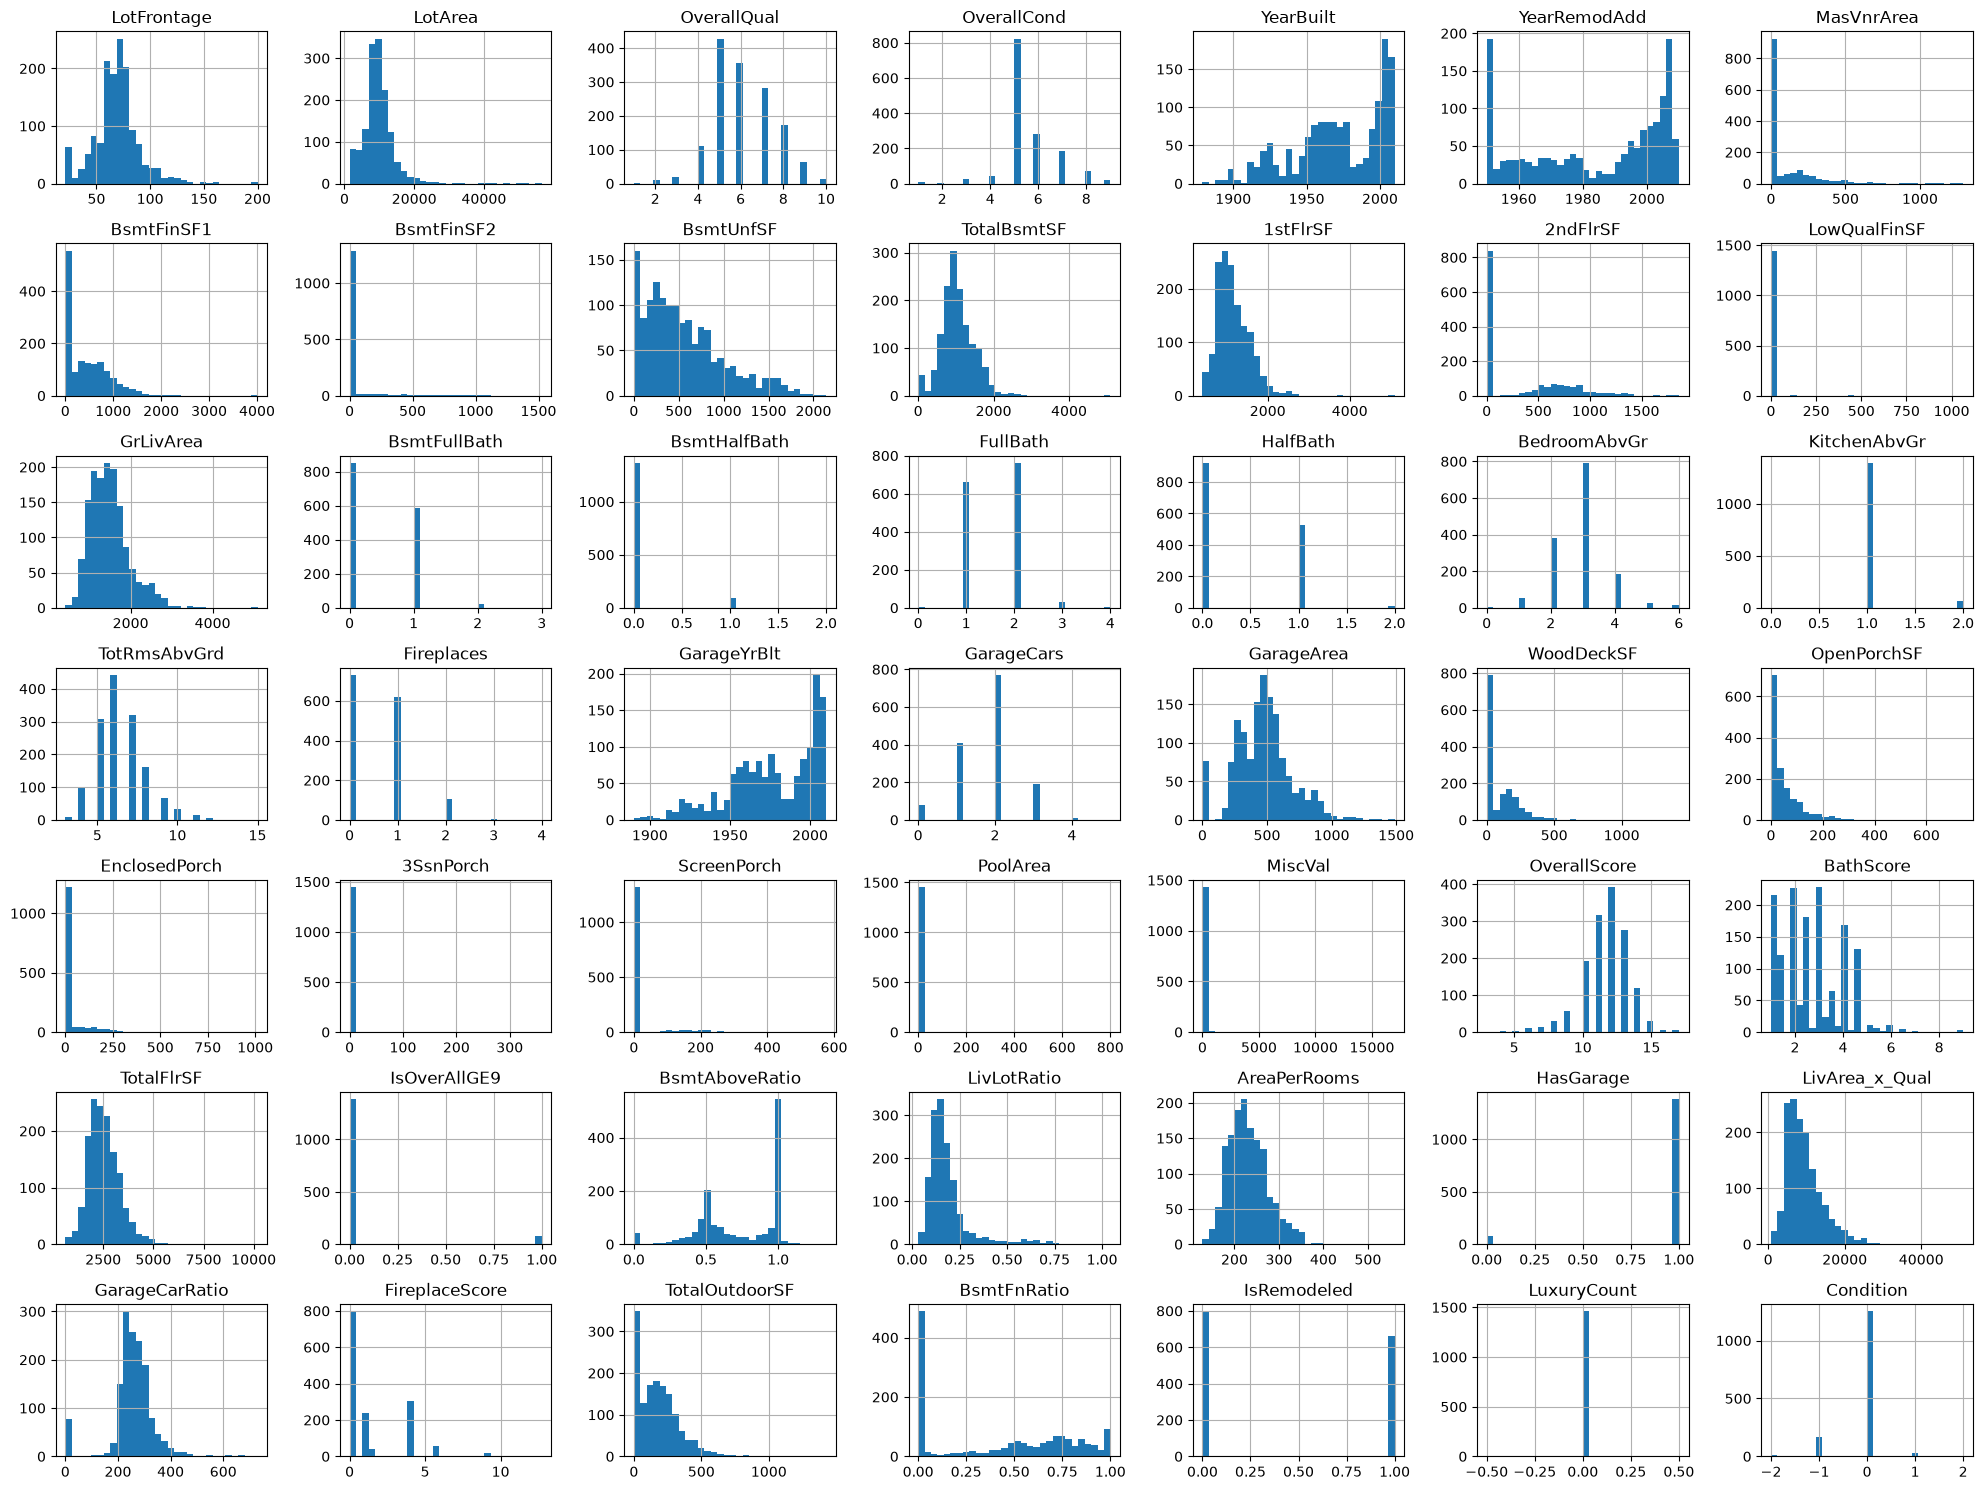

In [13]:
X_test.hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()